In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm
from scipy import optimize
import sympy

# Introduction to numerical methods

János Török

# Class 10: Boundary value problems and Green's function

# Ordinary differential equations


## Problem to Solve:

$$\frac{dx}{dt} = f(x,t)\; , \; x(t_0) = x_0 \qquad x(t) = ?$$

### Discrete Approximation

$$ dt \Rightarrow \Delta t \;, \quad dx \Rightarrow \Delta x$$ 

- Choose discrete values for $t$: $t_n = t_0 + n \Delta t$
- Our goal is to determine the function $x(t)$ point by point, that is, the values $x(t_n) = x_n$
- We approximate the differential equation with a difference equation.
- Solve this approximate equation and hope that the solution will be close to the solution of the differential equation.


### Explicit Euler method

$$ \frac{dx}{dt} \Rightarrow \frac{x_{n+1} - x_n}{\Delta t}$$
$$ f(x,t) \Rightarrow f(x_n,t_n)$$
* By substituting these, we get:
$$x_{n+1} = x_n + f(x_n, t_n) \Delta t$$

## First-Order Single-Variable Linear Differential Equation

### Example:

Solve the following differential equation numerically using the explicit Euler method.


$$x'(t) = -k \,x(t) \; , \quad x(0) = 1 \;, \qquad \textrm{azaz}\;  f(x,t) = -k x $$

Let us take $k = 1$.

In [2]:
#parameters:
dt = 0.1  #timestep
Npoints = 100 #number of steps
x0 = 1.
t0 = 0.
k = 1.

#arrays:
xlist = np.zeros(Npoints)
tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
xlist[0] = x0

#Solution:
for n in range(1,Npoints):
    xlist[n] = xlist[n-1] - k* xlist[n-1]*dt

### Analytic solution:
$$ x(t)= x_0e^{-kt}$$

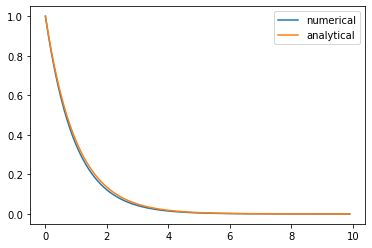

In [3]:
plt.plot(tlist,xlist,label="numerical")
plt.plot(tlist,x0*np.exp(-k*tlist),label="analytical")
plt.legend()
plt.show()

### Error and relative error:

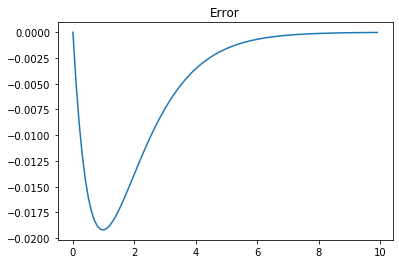

In [4]:
plt.plot(tlist,xlist-x0*np.exp(-k*tlist)) 
plt.title("Error")
plt.show()

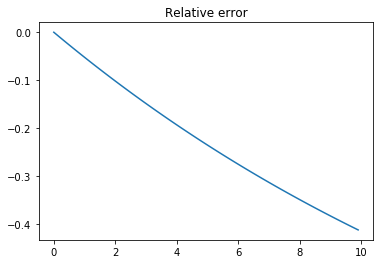

In [5]:
plt.plot(tlist,(xlist-x0*np.exp(-k*tlist))/(x0*np.exp(-k*tlist)))
plt.title("Relative error")
plt.show()

### Errors
The error vanishes but the relative error increases over time

### Write a function with excitation:
Let us write it for any dimenstion. All we need to do is to consider $x_0$ a vector and $k$ a matrix

## Multivariable First-Order Ordinary Differential Equations


$$ \frac{d \mathbf{x}}{dt} = f(\mathbf{x},t),$$
where $\mathbf{x} = (x^1, x^2, ..., x^m)$, and $

* The solution is very similar to the single-dimensional case.
* We will add the possibility of an external excitation $g(t)$
$$ \frac{d \mathbf{x}}{dt} - f(\mathbf{x},t) = g(t)$$

In [6]:
def explicit_euler(t0,x0,f,dt,Npoints,g=lambda x:0):
    #arrays:
    xlist = [x0]
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)

    #solution:
    for n in range(1,Npoints):
        xlist.append(xlist[-1] + (g(tlist[n])  - f(xlist[-1],tlist[n]))*dt)
    return tlist, np.array(xlist)

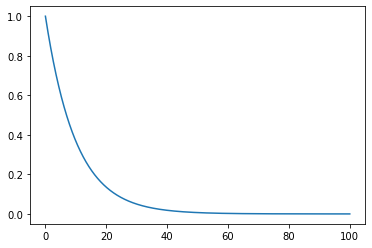

In [7]:
k = 0.1
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.01,Npoints=10000)
plt.plot(tlist,xlist)
plt.show()

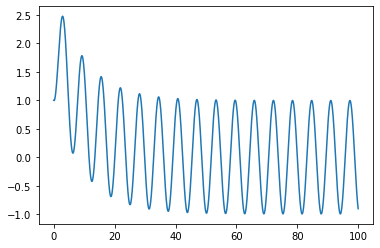

In [8]:
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.01,Npoints=10000,g=np.sin)
plt.plot(tlist,xlist)
plt.show()

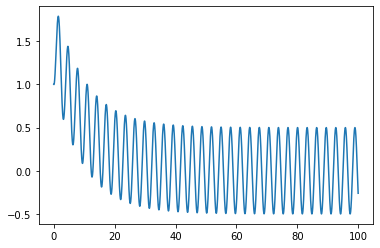

In [9]:
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.01,Npoints=10000,g=lambda t: np.sin(t*2))
plt.plot(tlist,xlist)
plt.show()

In [10]:
#Two dimensions
#parameters
dt = 0.002
Npoints = 10000
t0 = 0.
x0 = np.array([1.,0.])

A = np.array([[2.,-1.],
              [1, 3.]])

print(np.linalg.eig(A))

(array([2.5+0.8660254j, 2.5-0.8660254j]), array([[-0.35355339+0.61237244j, -0.35355339-0.61237244j],
       [ 0.70710678+0.j        ,  0.70710678-0.j        ]]))


In [11]:
tlist, xlist = explicit_euler(t0,x0,f=lambda x,t: np.dot(x,A),dt=dt,Npoints=Npoints)

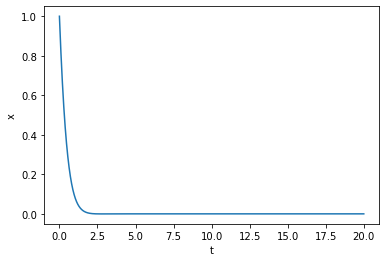

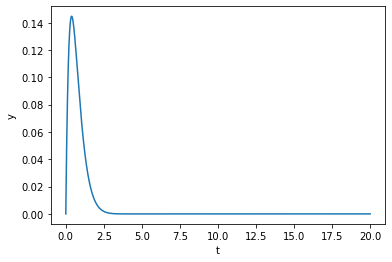

In [12]:
plt.plot(tlist,xlist[:,0])
plt.xlabel('t')
plt.ylabel('x')
plt.show()

plt.plot(tlist,xlist[:,1])
plt.xlabel('t')
plt.ylabel('y')
plt.show()

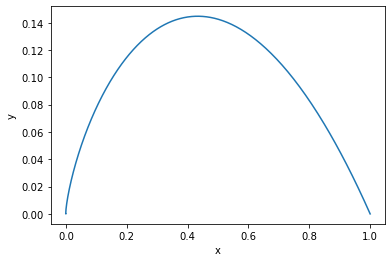

In [13]:
plt.plot(xlist[:,0], xlist[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

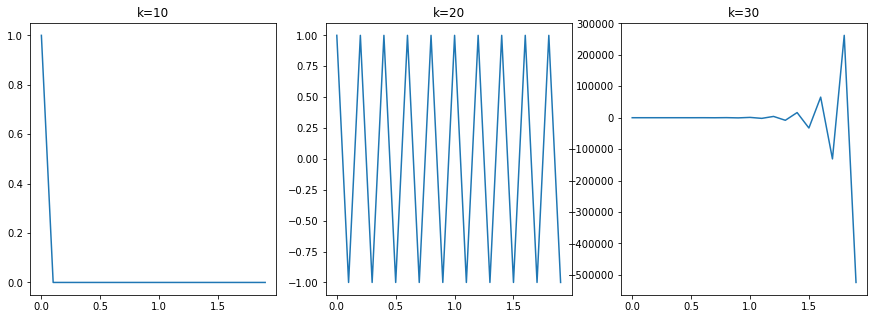

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

k = 10
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.1,Npoints=20)
ax[0].plot(tlist,xlist)
ax[0].set_title("k=10")
k = 20
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.1,Npoints=20)
ax[1].plot(tlist,xlist)
ax[1].set_title("k=20")
k = 30
tlist,xlist = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=0.1,Npoints=20)
ax[2].plot(tlist,xlist)
ax[2].set_title("k=30")
plt.show()

## Stability of the explicit Euler method

#### First in one dimension:

The Euler scheme is the following:
$$x_{n+1}=(1+k\Delta t)x_n$$
Which converges if
$$|1+k \Delta t| < 1$$
Please note that we defined $k$ with a negative sign.

#### Any dimensions:

Obviously that in out case the Euler scheme is linear. So we can transfer the problem to its eigensystem, where all components decay independently. The Eigenvalues must also satisfy the equation:
$$|1+\lambda \Delta t| < 1$$

## Implicit Euler method

Let us use the values of the function at time $t+1$:

$$x_{n+1} = x_n + \Delta t f(x_{n+1},t_{n+1})$$

We first need to solve the above algebraic equation for $x_{n+1}$-re. In our case for $f(x,t) = - k x$ it is simple
$$ x_{n+1} = \frac{x_{n}}{1 + k \, \Delta t } $$

In [15]:
def implicit_euler(t0,x0,k,dt,Npoints):
    #arrays:
    xlist = np.zeros(Npoints)
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist[0] = x0

    #Solution:
    for n in range(1,Npoints):
        xlist[n] = xlist[n-1]/(1+k*dt)
    return tlist, xlist

Let us try the preivous example

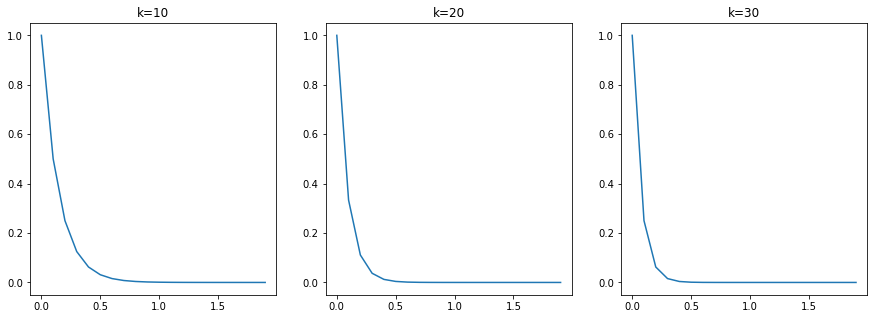

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

k = 10
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=20)
ax[0].plot(tlist,xlist)
ax[0].set_title("k=10")
k = 20
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=20)
ax[1].plot(tlist,xlist)
ax[1].set_title("k=20")
k = 30
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=20)
ax[2].plot(tlist,xlist)
ax[2].set_title("k=30")
plt.show()

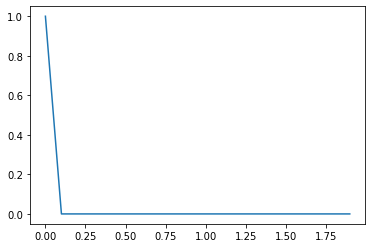

In [17]:
k = 1e100
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=20)
plt.plot(tlist,xlist)

### Stability of the implicit Euler method

Since for $k>0$
$$ \left|\frac{1}{1 + k \, \Delta t } \right| < 1$$
The implicit Euler method is always stable!

## Runge Kutta method
(From Wikipedia)
Let an initial value problem be specified as follows:

$$ \frac{dy}{dt} = f(t, y), \quad y(t_0) = y_0. $$

Here $y$ is an unknown function (scalar or vector) of time $t$, which we would like to approximate; we are told that $\frac{dy}{dt}$, the rate at which $y$ changes, is a function of $t$ and of $y$ itself. At the initial time $t_0$ the corresponding $y$ value is $y_0$. The function $f$ and the initial conditions $t_0$,  $y_0$ are given.

Now we pick a step-size $h>0$ and define:

$$\begin{align}
y_{n+1} &= y_n + \frac{h}{6}\left(k_1 + 2k_2 + 2k_3 + k_4 \right),\\
t_{n+1} &= t_n + h \\
\end{align}$$

for $n = 0, 1, 2, 3, \dots$
$$
\begin{align}
 k_1 &= \ f(t_n, y_n), \\
 k_2 &= \ f\!\left(t_n + \frac{h}{2}, y_n + h \frac{k_1}{2}\right), \\ 
 k_3 &= \ f\!\left(t_n + \frac{h}{2}, y_n + h \frac{k_2}{2}\right), \\
 k_4 &= \ f\!\left(t_n + h, y_n + h k_3\right).
\end{align}
$$

Here $y_{n+1}$ is the RK4 approximation of $y(t_{n+1})$, and the next value ($y_{n+1}$) is determined by the present value ($y_n$) plus the weighted average of four increments, where each increment is the product of the size of the interval, $h$, and an estimated slope specified by function $f$ on the right-hand side of the differential equation.
* $k_1$ is the slope at the beginning of the interval, using $ y $ (Euler's method);
* $k_2$ is the slope at the midpoint of the interval, using $ y $ and $ k_1 $;
* $k_3$ is again the slope at the midpoint, but now using $ y $ and $ k_2 $;
* $k_4$ is the slope at the end of the interval, using $ y $ and $ k_3 $.

In averaging the four slopes, greater weight is given to the slopes at the midpoint. If $f$ is independent of $y$, so that the differential equation is equivalent to a simple integral, then RK4 is Simpson's rule.

The RK4 method is a fourth-order method, meaning that the local truncation error is $O(h^5)$, while the total truncation error is on the order of $O(h^4)$.

In many practical applications the function $f$ is independent of $t$ (so called autonomous system, or time-invariant system, especially in physics), and their increments are not computed at all and not passed to function $f$, with only the final formula for $t_{n+1}$ used.

In [18]:
def rk4(t0,x0,f,dt,Npoints):
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist = np.zeros(Npoints)
    xlist[0] = x0
    x = x0
    for n in range(1,Npoints):
        t = tlist[n]
        k0 = dt*f(t, x)
        k1 = dt*f(t+dt/2, x+k0/2)
        k2 = dt*f(t+dt/2, x+k1/2)
        k3 = dt*f(t+dt, x+k2)
        x += (k0 + 2*k1 + 2*k2 + k3)/6
        xlist[n] = x
    return tlist, xlist

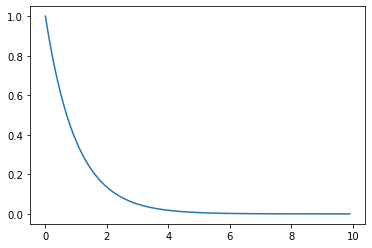

In [19]:
k = 1
tlist,xlist = rk4(t0=0,x0=1,f=lambda t,x: -k*x,dt=0.1,Npoints=100)
plt.plot(tlist,xlist)
plt.show()

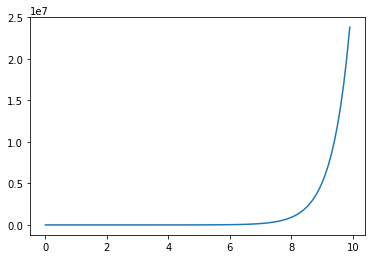

In [20]:
k = 29
tlist,xlist = rk4(t0=0,x0=1,f=lambda t,x: -k*x,dt=0.1,Npoints=100)
plt.plot(tlist,xlist)
plt.show()

### Which method is better?

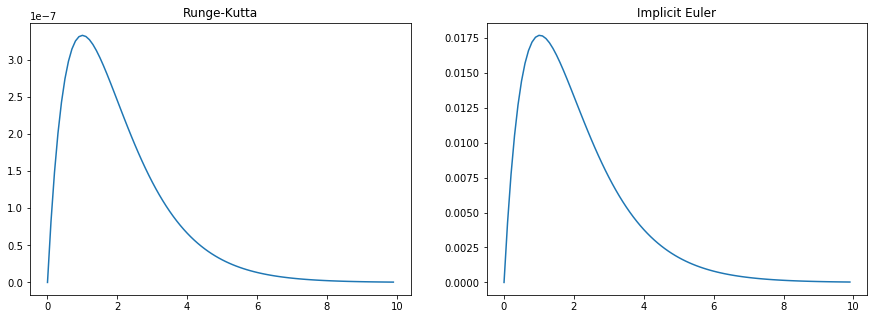

In [21]:
#Error
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
k = 1
x0 = 1
tlist,xlist = rk4(t0=0,x0=1,f=lambda t,x: -k*x,dt=0.1,Npoints=100)
ax[0].plot(tlist,xlist-x0*np.exp(-k*tlist)) 
ax[0].set_title("Runge-Kutta")
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=100)
ax[1].plot(tlist,xlist-x0*np.exp(-k*tlist)) 
ax[1].set_title("Implicit Euler")
plt.show()

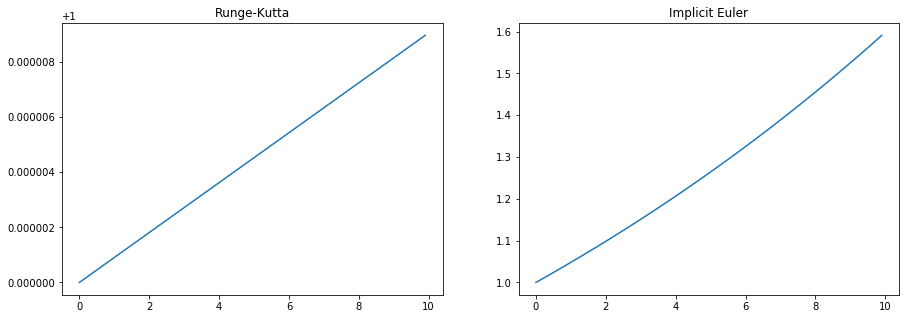

In [22]:
#relative error
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
k = 1
x0 = 1
tlist,xlist = rk4(t0=0,x0=1,f=lambda t,x: -k*x,dt=0.1,Npoints=100)
ax[0].plot(tlist,xlist/(x0*np.exp(-k*tlist)) )
ax[0].set_title("Runge-Kutta")
tlist,xlist = implicit_euler(t0=0,x0=1,k=k,dt=0.1,Npoints=100)
ax[1].plot(tlist,xlist/(x0*np.exp(-k*tlist)) )
ax[1].set_title("Implicit Euler")
plt.show()

## Newton's equations of motion, second order differential equations
$$m \ddot x=F$$
With the initial values:
$$x(t=0)=x_0, \qquad \dot x(t=0)=v_0$$

We can split it into two first order differential equations:
$$\begin{align}
\dot v &= F\\
\dot x &= v
\end{align}$$

### Let us try the harmonic oscillator
$$ F(x) = -kx$$

In [23]:
k=1
tlist,xlist = explicit_euler(t0=0,x0=[1,0],f=lambda x,t:np.array([x[1],-k*x[0]]),dt=0.01,Npoints=10000)

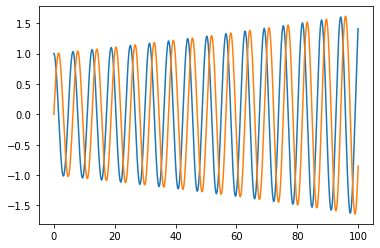

In [24]:
plt.plot(tlist,xlist);

In [25]:
def rk4N(t0,x0,v0,f,dt,Npoints):
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist = np.zeros(Npoints)
    vlist = np.zeros(Npoints)
    xlist[0] = x0
    vlist[0] = v0
    x = x0
    v = v0
    t = t0
    for n in range(1,Npoints):
        #t = tlist[n-1] 
        k1v = f(x, t) * dt
        k1x = v * dt
        k2v = f(x + k1x/2, t + dt/2) * dt
        k2x = (v + k1v/2) * dt
        # in next line u should use k2x
        # cf. https://www.compadre.org/PICUP/resources/Numerical-Integration/
        k3v = f(x + k2x/2, t + dt/2) * dt
        k3x = (v + k2v/2) * dt
        # in next line u should use k3x
        k4v = f(x + k3x, t + dt) * dt
        k4x = (v + k3v) *dt
        v += (k1v + 2*k2v + 2*k3v + k4v) / 6
        x += (k1x + 2*k2x + 2*k3x + k4x) / 6
        xlist[n] = x
        vlist[n] = v
        t = tlist[n]
    return tlist, xlist, vlist

In [26]:
def rk4N(t0,x0,v0,f,dt,Npoints):
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist = np.zeros(Npoints)
    vlist = np.zeros(Npoints)
    xlist[0] = x0
    vlist[0] = v0
    x = x0
    v = v0
    t = t0
    for n in range(1,Npoints):
        #t = tlist[n-1] 
        k1v = f(x, t) * dt
        k1x = v * dt
        k2v = f(x + k1x/2, t + dt/2) * dt
        k2x = (v + k1v/2) * dt
        k3v = f(x + k2v/2, t + dt/2) * dt
        k3x = (v + k2v/2) * dt
        k4v = f(x + k3v, t + dt) * dt
        k4x = (v + k3v) *dt
        v += (k1v + 2*k2v + 2*k3v + k4v) / 6
        x += (k1x + 2*k2x + 2*k3x + k4x) / 6
        xlist[n] = x
        vlist[n] = v
        t = tlist[n]
    return tlist, xlist, vlist

In [27]:
k=1
tlist,xlist,vlist = rk4N(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)

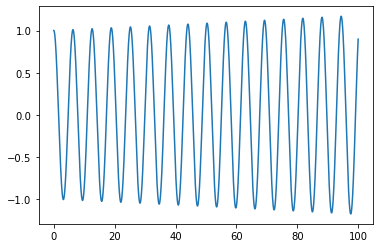

In [28]:
plt.plot(tlist,xlist)

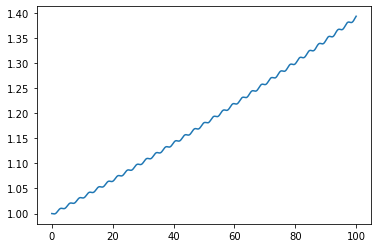

In [29]:
plt.plot(tlist,vlist**2+k*xlist**2)

### Implicit Euler for Newton's equation of motion

$$m \ddot x=F$$
With the initial values:
$$x(t=0)=x_0, \qquad \dot x(t=0)=v_0$$


The Euler method
$$\begin{align}
v_{n+1} &= v_n + f(x_n) \Delta t\\
x_{n+1} &= x_n + v_n \Delta t
\end{align}$$

However in the last step we can use the velocity at timestep $n+1$, which is the <b>implicit Euler method</b>:

$$\begin{align}
v_{n+1} &= v_n + f(x_n) \Delta t\\
x_{n+1} &= x_n + v_{n+1} \Delta t
\end{align}$$



In [30]:
def implicit_eulerN(t0,x0,v0,f,dt,Npoints):
    #arrays:
    xlist = np.zeros(Npoints)
    vlist = np.zeros(Npoints)
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist[0] = x0
    vlist[0] = v0

    #Solution:
    for n in range(1,Npoints):
        vlist[n] = vlist[n-1] + f(xlist[n-1],tlist[n]) * dt
        xlist[n] = xlist[n-1] + vlist[n] * dt
    return tlist, xlist, vlist

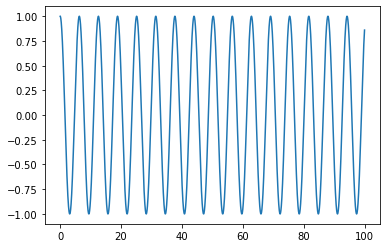

In [31]:
k=1
tlist,xlist,vlist = implicit_eulerN(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)
plt.plot(tlist,xlist)

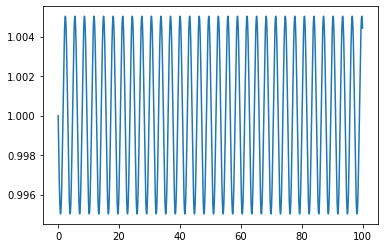

In [32]:
plt.plot(tlist,vlist**2+k*xlist**2)

### Error
The error is larger than for Runge-Kutta, but it does not drift. Implicit Euler is a symplectic integrator, which means that the method conserves a symplectic scalar product, in our case the total energy plus some virtual part.

## Velocity Verlet
A related, and more commonly used algorithm is the velocity Verlet algorithm, similar to the leapfrog method, except that the velocity and position are calculated at the same value of the time variable (leapfrog does not, as the name suggests). This uses a similar approach, but explicitly incorporates velocity, solving the problem of the first time step in the basic Verlet algorithm:

$$\begin{align}
\mathbf{x}(t + \Delta t) &= \mathbf{x}(t) + \mathbf{v}(t)\, \Delta t + \tfrac{1}{2} \,\mathbf{a}(t) \Delta t^2, \\[6pt]
\mathbf{v}(t + \Delta t) &= \mathbf{v}(t) + \frac{\mathbf{a}(t) + \mathbf{a}(t + \Delta t)}{2} \Delta t.
\end{align}$$

It can be shown that the error in the velocity Verlet is of the same order as in the basic Verlet. Note that the velocity algorithm is not necessarily more memory-consuming, because, in basic Verlet, we keep track of two vectors of position, while in velocity Verlet, we keep track of one vector of position and one vector of velocity. The standard implementation scheme of this algorithm is:
 1. Calculate $\mathbf{v}\left(t + \tfrac12\,\Delta t\right) = \mathbf{v}(t) + \tfrac12\,\mathbf{a}(t)\,\Delta t$.
 2. Calculate $\mathbf{x}(t + \Delta t) = \mathbf{x}(t) + \mathbf{v}\left(t + \tfrac12\,\Delta t\right)\, \Delta t$.
 3. Derive $\mathbf{a}(t + \Delta t)$ from the interaction potential using $\mathbf{x}(t + \Delta t)$.
 4. Calculate $\mathbf{v}(t + \Delta t) = \mathbf{v}\left(t + \tfrac12\,\Delta t\right) + \tfrac12\,\mathbf{a}(t + \Delta t)\Delta t$.
This algorithm also works with variable time steps, and is identical to the 'kick-drift-kick' form of leapfrog method integration.

Eliminating the half-step velocity, this algorithm may be shortened to
 1. Calculate $\mathbf{x}(t + \Delta t) = \mathbf{x}(t) + \mathbf{v}(t)\,\Delta t + \tfrac12 \,\mathbf{a}(t)\,\Delta t^2$.
 2. Derive $\mathbf{a}(t + \Delta t)$ from the interaction potential using $\mathbf{x}(t + \Delta t)$.
 3. Calculate $\mathbf{v}(t + \Delta t) = \mathbf{v}(t) + \tfrac12\,\bigl(\mathbf{a}(t) + \mathbf{a}(t + \Delta t)\bigr)\Delta t$.

Note, however, that this algorithm assumes that acceleration $\mathbf{a}(t + \Delta t)$ only depends on position $\mathbf{x}(t + \Delta t)$ and does not depend on velocity $\mathbf{v}(t + \Delta t)$.

One might note that the long-term results of velocity Verlet, and similarly of leapfrog are one order better than the semi-implicit Euler method. The algorithms are almost identical up to a shift by half a time step in the velocity.  This can be proven by rotating the above loop to start at step 3 and then noticing that the acceleration term in step 1 could be eliminated by combining steps 2 and 4.  The only difference is that the midpoint velocity in velocity Verlet is considered the final velocity in semi-implicit Euler method.

The global error of all Euler methods is of order one, whereas the global error of this method is, similar to the midpoint method, of order two. Additionally, if the acceleration indeed results from the forces in a conservative mechanical or Hamiltonian system, the energy of the approximation essentially oscillates around the constant energy of the exactly solved system, with a global error bound again of order one for semi-explicit Euler and order two for Verlet-leapfrog. The same goes for all other conserved quantities of the system like linear or angular momentum, that are always preserved or nearly preserved in a symplectic integrator.<ref name="Hairer2003" />


In [79]:
def velocity_verlet(t0,x0,v0,f,dt,Npoints):
    xlist = np.zeros(Npoints)
    vlist = np.zeros(Npoints)
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist[0] = x0
    vlist[0] = v0
    a = f(xlist[0],tlist[0])

    for n in range(1,Npoints):
        xlist[n] = xlist[n-1] + vlist[n-1]*dt + 0.5*a*dt*dt
        vlist[n] = vlist[n-1] + 0.5*a*dt
        a = f(xlist[n],tlist[n])
        vlist[n] = vlist[n] + 0.5*a*dt
    return tlist, xlist, vlist

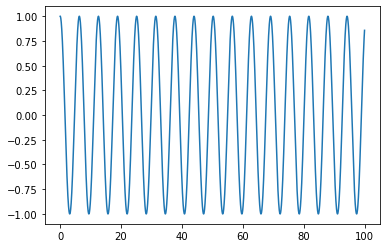

In [34]:
k=1
tlist,xlist,vlist = velocity_verlet(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)
plt.plot(tlist,xlist)

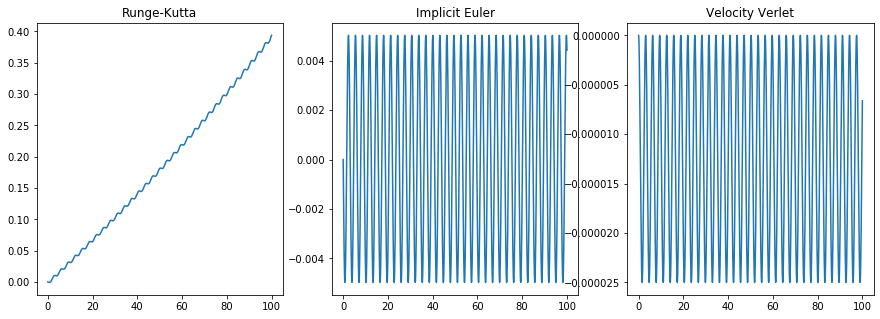

In [35]:
k = 1
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
tlist,xlist,vlist = rk4N(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)
ax[0].plot(tlist,vlist**2+k*xlist**2-1)
ax[0].set_title("Runge-Kutta")
tlist,xlist,vlist = implicit_eulerN(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)
ax[1].plot(tlist,vlist**2+k*xlist**2-1)
ax[1].set_title("Implicit Euler")
tlist,xlist,vlist = velocity_verlet(t0=0,x0=1,v0=0,f=lambda x,t:-k*x,dt=0.01,Npoints=10000)
ax[2].plot(tlist,vlist**2+k*xlist**2-1)
ax[2].set_title("Velocity Verlet")
plt.show()

# Green's function
Let us briefly go back to first order differential equations in its linear form:
$$\frac{dx}{dt}+kx=g(t),$$
where $g(t)$ is the excitation, and here we assumed time independent differential equation. Let us transform this equation to Fourier space:
$$i\omega \widehat x + k\widehat x= \widehat g$$
Which as anlgebraic equation for the Fourier transform of $x$:
$$\widehat x=\frac{\widehat g}{i\omega +k}$$
Let us test it!
$$g(t) = \sin(0.1t)e^{-0.01t}$$

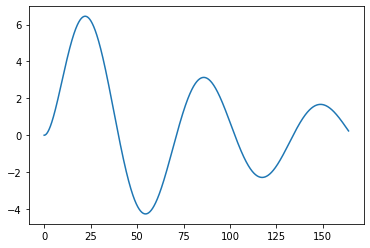

In [36]:
#Explicit Euler
k = 0.1
dt = 0.01
Npoints = 2**14
T = Npoints*dt
tlist,xlist = explicit_euler(t0=0,x0=0,f=lambda x,t: k*x,dt=dt,Npoints=Npoints,g=lambda x:np.sin(0.1*x)*np.exp(-0.01*x))
plt.plot(tlist,xlist)

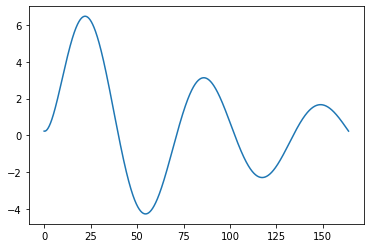

In [37]:
# Fourier transformation
# get the frequencies right!
w = np.fft.fftfreq(Npoints, d=dt) * 2 * np.pi
xx = np.fft.ifft(np.fft.fft(np.sin(tlist*0.1)*np.exp(-0.01*tlist))/(1.j * w + k))
plt.plot(tlist,np.real(xx))

### Observations
The two curves look identical. We can solve the differential equation by Transforming the excitation to Fourier space then dividing it by the Fourier transform of the differential equation and finally transforming back. Let us also note that we have set the initial condition to zero. Setting the correct one can be done in Fourier space but it is not nice and there is a better way. Moreover in case of excited systems one is often interested in the long term behaviour.

# Green's function
Let us have a linear system with $f_i(t)$ as the input and $x_i(t)$ the output, then the following relations hold:
$$
\begin{align}
[f_1(t)+f_2(t)]&\to [x_1(t)+x_2(t)]\\
[af_1(t)]&\to [ax_1(t)]
\end{align}
$$
We are interested in the output generated by a given input $f(t)$.

Let us cut our excitation to two parts $f_+(t) = f(t)|_{t>t_0}$ and $f_-(t) = f(t)|_{t\leq t_0}$ and they generate $x_+(t)$ and $x_-(t)$ respectiely. Oviously since $f(x) = f_+(t)+f_-(t)$ we also have $x(t)=x_+(t)+x_-(t)$. Now instead of cutting into two parts we cut $f(t)$ into $dt$ sized parts. Obviously the output $x(t)$ will be the sum of the effect of all these infinitesimal excitations. Of course the excitation at time $t'$ may have effects at other times $t$ (if you hit a pendulum it may swing for a long time). Since the system is linear the output at time $t$ will have the sum of the effects of the small exitations at every time point $t'$.This can be written in the most general case in the following form:
$$
x(t)=\int_{-\infty}^\infty G(t,t')f(t')dt',
$$
where $G(t,t')$ is called the Green's function and accounts for the effect of the excitation at time $t'$ to the output at time $t$.

Oviously excitations in the future cannot have effect on the present state of the output. So the integral only tuns up to $t$:
$$
x(t)=\int_{-\infty}^t G(t,t')f(t')dt'.
$$
Furthermore we will assume that we have a time invariant system. This means that the system produced the same output every time the same experiment is run. The only important variable is the elapsed time $\tau$ between the excitation $t'$ and the output $t$. So using $\tau\equiv t-t'$ we get:
$$
x(t)=\int_{0}^\infty G(\tau)f(t-\tau)d\tau.
$$
It is important to note that $\tau=t-t'$. So it measures how far in the past the exitation was. So $\tau=0$ is the present and $\tau>0$ is the past. Obviously $\tau<0$ is the future. The future cannot have any effect to the present. Hence the integral starts at $0$. Alternatively we may set $G(\tau<0) \equiv 0$m which allows us to rewrite the equation to be a full convolution:
$$
x(t)=\int_{-\infty}^\infty G(\tau)f(t-\tau)d\tau.
$$

The whole process is indicated in the following figure:
<center><img src="class11/Greenlev.png" width="350px"></center>

### Calculation of the Green's function
The Green's function helps us to find the response to any excitation through a simple convolution. Thus a simple integration solves the answer to an arbitrary excitation. The next task we face is the calculation of the Green's function. Let us recall the definition of the Dirac delta 
$$G(t) = \int_{-\infty}^\infty G(\tau)\delta(t-\tau)d\tau$$
So if the excitation is a Dirac delta the response will be the Green's function. Let us write the differential equation with the Dirac delta as excitation
$$\frac{dx}{dt}+kx=\delta(t)$$
Since $\delta(t)$ is almost always zero (except for $t=0$) this is just the homogene equation with initial condition at $t=0$. This initial condition can be obtained from the integration between $-\varepsilon$ and $\varepsilon$:
$$\begin{align}
\int_{-\varepsilon}^{\varepsilon}\left(\frac{dx}{dt}+kx\right)dt&=\int_{-\varepsilon}^{\varepsilon}\delta(t)dt\\
x(t=\varepsilon)-x(t=-\varepsilon) + 2kx\varepsilon &= 1\\
x(t=\varepsilon) &= 1
\end{align}$$
We used that if $\varepsilon$ is small then since $k$ and $x$ is finite we can neglect the second term in the left hand side of the equation and since $\delta(t)=0$ for $t<0$, so $x(t<0)=0$.

In summary the Dirac delta excitation is identical to a boundary condition with $x(t=0)=1$.


### Green's function in real space
Let us try our results:

4.3607320616826455e-05


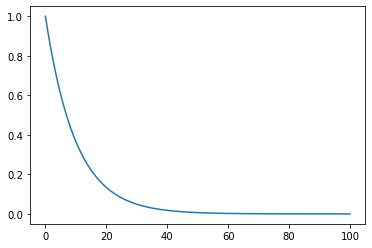

In [72]:
#Calculate The Green's function
k = .1
tlist, G = explicit_euler(t0=0,x0=1,f=lambda x,t: k*x,dt=dt,Npoints=1000)
plt.plot(tlist,G)
print(G[-1])

In [73]:
def convolution_o(t,G,f,tlist):
    I = 0.0
    for i,tau in enumerate(tlist):
        if t-tau>0:
            I += f(t-tau) * G[i]
    return(I)

In [74]:
dt = 0.1
Npoints = 2**14//10
xt = np.zeros(Npoints,dtype=float)
tt = np.arange(Npoints) * dt
for i in range(Npoints):
    xt[i] = convolution_o(tt[i],G,lambda t:np.sin(t*0.1)*np.exp(-0.01*t),tlist)*dt

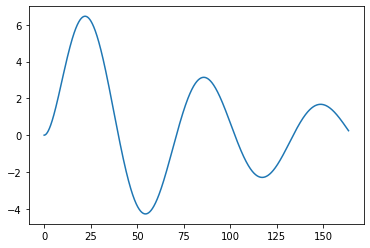

In [75]:
plt.plot(tt,xt)

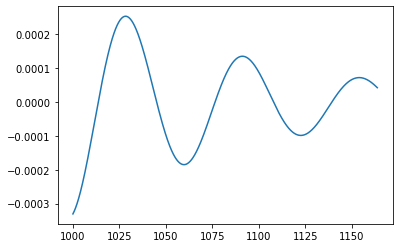

In [77]:
dt = 0.1
Npoints = 2**14//10
xt = np.zeros(Npoints,dtype=float)
tt = np.arange(Npoints) * dt + 1000
for i in range(Npoints):
    xt[i] = convolution_o(tt[i],G,lambda t:np.sin(t*0.1)*np.exp(-0.01*t),tlist)*dt
plt.plot(tt,xt)

In [76]:
def convolution(t,G,f,tlist):
    return (f(t-tlist) * G).sum()

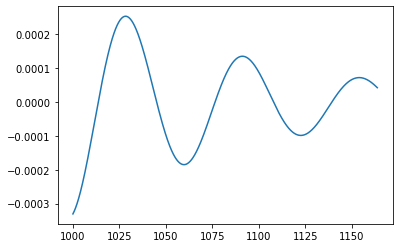

In [78]:
dt = 0.1
Npoints = 2**14//10
xt = np.zeros(Npoints,dtype=float)
tt = np.arange(Npoints) * dt + 1000
for i in range(Npoints):
    xt[i] = convolution(tt[i],G,lambda t:np.sin(t*0.1)*np.exp(-0.01*t),tlist)*dt
plt.plot(tt,xt)

## Green's function in real space: summary

The Green's function the the response of the linear system to a Dirac delta excitation. When convoluted with an excitation we get back the output of the system. Needs a double loop, the inside up to the relevant part of the Green's function (which is decreasing and goes to zero, so it should be fine) and then for the number of points we want to recreate.

# Green's function in Fourier space
The convolution in Fourier space is a simple product:
$${\cal F}\left[(f\ast g)(t) \right]= {\cal F}\left[\int_{-\infty}^\infty f(\tau)g(t-\tau)d\tau \right]= \sqrt{2\pi}\widehat{f}(\omega)\widehat {g}(\omega)$$
So using our previous result:
$$\widehat{x}(\omega) = \sqrt{2\pi}\widehat{G}(\omega)\widehat {f}(\omega),$$
where $\widehat{G}(\omega)$ is the Fourier transform of the Green's function and $\widehat {f}(\omega)$ is the Fourier transform of the exutation.

Please note that the Fourier transform of the Green's function can be easily obtained from the differential equation using the Dirac delta as the excitation:
$$
\begin{align}
\frac{dG}{dt}+kG&=\delta(t)\\
{\cal F}\left[\frac{dG}{dt}\right] +k\widehat{G}&=\frac{1}{\sqrt{2\pi}}\\
(i\omega + k) \widehat{G}(\omega)&=\frac{1}{\sqrt{2\pi}}\\
\widehat{G}(\omega)&=\frac{1}{\sqrt{2\pi}}\frac{1}{i\omega + k}
\end{align}$$
Finally the Fuirier transform of the response:
$$\widehat{x}(\omega) = \frac{\widehat{f}}{i\omega + k}.$$
Exactly as above!

### Application to damped harmonic oscillator
$$\begin{align}
\ddot x+2\alpha\dot x+\omega_0^2 x&=f(t)\\
-\omega^2 \tilde x(\omega)+i\omega \widehat X(\omega)+\omega_0^2 \widehat
x(\omega) &= \widehat f(\omega)\\
\widehat x(\omega)\left(-\omega^2+2i\alpha\omega+\omega_0^2\right) &=\widehat
f(\omega)
\end{align}
$$
Moreover
$$\widehat{x}(\omega) = \sqrt{2\pi}\widehat{G}(\omega)\widehat {f}(\omega)$$
This gives
    $$\widehat G(\omega)=\frac{1}{\sqrt{2\pi}}
\frac{1}{(-\omega^2+2i\alpha\omega+\omega_0^2)}$$

The Green's function in Euler's form
$$\widehat G(\omega)=\left|\widehat G(\omega)\right|e^{-i\gamma}$$
Since
$$2\pi\widehat G(\omega)=\frac{(\omega_0^2-\omega^2)-i2\alpha\omega}
{(\omega_0^2-\omega^2)^2+4\alpha^2\omega^2}$$
We get
$$\begin{align}
\tan\gamma &= -\frac{2\alpha\omega}{\omega_0^2-\omega^2}\\
\left|\widehat G(\omega)\right|&=\frac{1}
{2\pi\sqrt{(\omega_0^2-\omega^2)^2+4\alpha^2\omega^2}}
\end{align}$$


<center>
<img src="class11/linoscatvfv.png" width=800px>
</center>

This gives a resonance at $\omega_R=\sqrt{\omega_0^2-2\alpha^2}$ and the phase changes sign after this.

In [93]:
def velocity_verlet_exc(t0,x0,v0,f,dt,Npoints,g):
    xlist = np.zeros(Npoints)
    vlist = np.zeros(Npoints)
    tlist = np.arange(t0,t0 + (Npoints)*dt,dt)
    xlist[0] = x0
    vlist[0] = v0
    a = f(xlist[0],vlist[0]) + g(tlist[0])

    for n in range(1,Npoints):
        xlist[n] = xlist[n-1] + vlist[n-1]*dt + 0.5*a*dt*dt
        vlist[n] = vlist[n-1] + 0.5*a*dt
        a = f(xlist[n],vlist[n]) + g(tlist[n])
        vlist[n] = vlist[n] + 0.5*a*dt
    return tlist, xlist, vlist

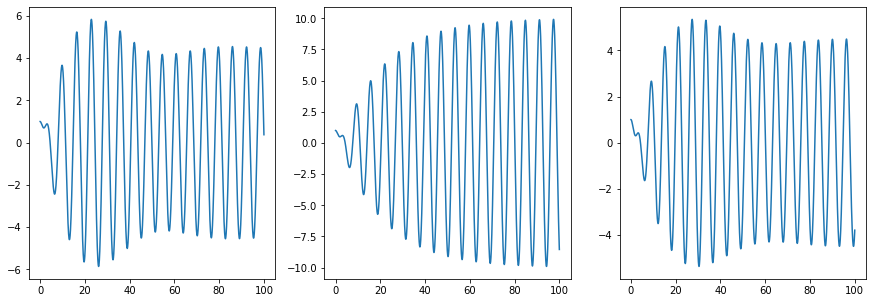

In [100]:
k=0.1
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
w02 = 0.8
tlist,xlist,vlist = velocity_verlet_exc(t0=0,x0=1,v0=0,f=lambda x,v:-k*v-w02*x,dt=0.01,Npoints=10000,g=lambda t:np.sin(t))
ax[0].plot(tlist,xlist)
w02 = 1
tlist,xlist,vlist = velocity_verlet_exc(t0=0,x0=1,v0=0,f=lambda x,v:-k*v-w02*x,dt=0.01,Npoints=10000,g=lambda t:np.sin(t))
ax[1].plot(tlist,xlist)
w02 = 1.2
tlist,xlist,vlist = velocity_verlet_exc(t0=0,x0=1,v0=0,f=lambda x,v:-k*v-w02*x,dt=0.01,Npoints=10000,g=lambda t:np.sin(t))
ax[2].plot(tlist,xlist)